# Self Corrective RAG

In [1]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions langchain-text-splitters

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━

In [149]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY').strip()

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [3]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.3-70b-versatile")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="qwen/qwen3-next-80b-a3b-instruct:free",
#     temperature=0.8,
# )

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
import warnings

warnings.filterwarnings("ignore")

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

In [7]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [168]:
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000,
    chunk_overlap=200,
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to VectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)

retriever = vectorstore.as_retriever()

In [169]:
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
)

#### Let's look into the retriever grader

In [170]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from pydantic import BaseModel, Field

# Data Model
class GradeDocuments(BaseModel):
  """Binary score for relevance check on retrieved documents."""

  binary_score: str = Field(
      description="Documents are relevant to the question, 'yes' or 'no'"
  )

In [171]:
# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [172]:
#Prompt
system="""You are a grader checking if a document is relevant to a user’s question.The check has to be done very strictly..
If the document has words or meanings related to the question, mark it as relevant.
Give a simple 'yes' or 'no' answer to show if the document is relevant or not."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [173]:
grade_prompt

ChatPromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="You are a grader checking if a document is relevant to a user’s question.The check has to be done very strictly..\nIf the document has words or meanings related to the question, mark it as relevant.\nGive a simple 'yes' or 'no' answer to show if the document is relevant or not."), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, template='Retrieved document: \n\n {document} \n\n User question: {question}'), additional_kwargs={})])

In [174]:
my_retrieval_grader = grade_prompt | structured_llm_grader
question = "What is an AI Agent?"

In [175]:
docs = retriever.invoke(question)

In [176]:
doc_txt = docs[2].page_content

In [177]:
doc_txt

"LLM Powered Autonomous Agents | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\n\n\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality 

In [178]:
print(my_retrieval_grader.invoke({"document": doc_txt, "question": question}))

binary_score='yes'


In [179]:
question = "Who is Yosuf Paryani?"

In [180]:
print(my_retrieval_grader.invoke({"document": doc_txt, "question": question}))

binary_score='no'


### let's look into the data generation

In [181]:
### Generate

from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)
prompt.pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [182]:
docs

[Document(metadata={'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in

In [183]:
rag_chain = prompt | llm

In [184]:
question = "What is an AI Agent?"

In [185]:
# Run
generation = rag_chain.invoke({"context": docs, "question": question})

In [186]:
generation

AIMessage(content='An AI agent is a system where a large language model serves as the “brain,” orchestrating tasks through planning, memory, and tool‑use components. It decomposes complex goals into subgoals, reflects on past actions to refine its behavior, and leverages short‑term (in‑context) and long‑term (external vector store) memory to retain knowledge. By calling external APIs for up‑to‑date data or execution, the agent can act autonomously and solve problems beyond simple text generation.', additional_kwargs={'reasoning_content': "We need to answer: What is an AI Agent? Use the context. Summarize concisely, max 3 sentences. We can say: An AI agent is a system where a large language model acts as the brain, with planning, memory, and tool use components. It breaks tasks into subgoals, reflects on actions, uses short-term and long-term memory, and can call external APIs for additional info. It's essentially a general problem solver powered by LLM. We'll keep within 3 sentences."}

### Hallucination Grader

In [187]:
# Data model
class GradeHallucination(BaseModel):
  """Binary score for hallucination present in generation answer."""

  binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

In [188]:
# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeHallucination)

In [189]:
# Prompt
system = """You are a grader checking if an LLM generation is grounded in or supported by a set of retrieved facts.
Give a simple 'yes' or 'no' answer. 'Yes' means the generation is grounded in or supported by a set of retrieved the facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

In [190]:
hallucinations_grader = hallucination_prompt | structured_llm_grader

In [191]:
print(hallucinations_grader.invoke({"documents": docs, "generation": generation}))

binary_score='yes'


#### Answer Grader

In [192]:
## Answer Grader
# Data Model
class GradeAnswer(BaseModel):
  """Binary score to assess answer addresses question."""

  binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}")
    ]

)

answer_grader = answer_prompt | structured_llm_grader
print(answer_grader.invoke({"question": question, "generation": generation}))

binary_score='yes'


### Question Re-writer

In [193]:
from langchain_core.output_parsers import StrOutputParser

system = """You are a question re-writer that converts an input question into a better optimized version for vector store retrieval document.
You are given both a question and a document.
- First, check if the question is relevant to the document by identifying a connection or relevance between them.
- If there is a little relevancy, rewrite the question based on the semantic intent of the question and the context of the document.
- If no relevance is found, simply return this single word "question not relevant." dont return the entire phrase
Your goal is to ensure the rewritten question aligns well with the document for better retrieval."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human", """Here is the initial question: \n\n {question} \n,
             Here is the document: \n\n {documents} \n ,
             Formulate an improved question. if possible other return 'question not relevant'."""
        ),

    ]
)
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [194]:
question = "Who is a current President of China?"

In [195]:
question_rewriter.invoke({"question": question, "documents": docs})

'question not relevant'

In [196]:
from typing import List
from typing_extensions import TypedDict

class AgentState[TypedDict]:
  question: str
  generation: str
  documents: List[str]
  filter_documents: List[str]
  unfilter_documents: List[str]

In [197]:
def retrieve(state: AgentState):
  print("----RETRIEVE----")
  question = state["question"]
  documents = retriever.invoke(question)
  return {"documents": documents, "question": question}

In [198]:
def grade_documents(state: AgentState):
  print("----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----")
  question = state["question"]
  documents = state["documents"]

  filtered_docs = []
  unfiltered_docs = []

  for doc in documents:
    score = my_retrieval_grader.invoke({"question": question, "document": doc})
    grade = score.binary_score
    if grade == "yes":
      print("----GRADE: DOCUMENT RELEVANT----")
      filtered_docs.append(doc)
    else:
      print("----GRADE: DOCUMENT NOT RELEVANT----")
      unfiltered_docs.append(doc)

  if len(unfiltered_docs)>1:
    return {"unfilter_documents": unfiltered_docs, "filter_documents": [], "question": question}
  else:
    return {"filter_documents": filtered_docs, "unfilter_documents": [], "question": question}


In [199]:
def decide_to_generate(state: AgentState):
  print("----ACCESS GRADED DOCUMENTS----")
  state["question"]
  unfiltered_documents = state["unfilter_documents"]
  filtered_documents = state["filter_documents"]


  if unfiltered_documents:
    print("----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----")
    return "transform_query"
  if filtered_documents:
    print("----DECISION: GENERATE----")
    return "generate"

In [200]:
def generate(state: AgentState):
  print("----GENERATE----")
  question = state["question"]
  documents = state["documents"]

  generation = rag_chain.invoke({"context": documents, "question": question})
  return {"documents": documents, "question": question, "generation": generation}

In [201]:
from langgraph.graph import END, StateGraph, START
def transform_query(state: AgentState):
  question = state["question"]
  documents = state["documents"]

  print(f"this is my document{documents}")
  response = question_rewriter.invoke({"question":question,"documents":documents})
  print(f"----RESPONSE---- {response}")

  if response == "question not relevant":
    print("----QUESTION IS NOT AT ALL RELEVANT----")
    return {"documents": documents, "question": response, "generation": "question was not at all relevant"}
  else:
    return {"documents": documents, "question": response}




In [202]:
def decide_to_generate_after_transformation(state: AgentState):
  question = state["question"]

  if question == "question not relevant":
    return "query_not_at_all_relevant"
  else:
      return "Retriever"

In [203]:
import pprint
def grade_generation_vs_documents_and_question(state: AgentState):
  print("---CHECK HELLUCINATIONS---")
  question = state["question"]
  documents = state["documents"]
  generation = state["generation"]

  score = hallucinations_grader.invoke({"documents": documents, "generation": generation})

  grade = score.binary_score


  # Check halluncinations
  if grade == "yes":
    print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")

    print("---GRADE GENERATION vs QUESTION ---")

    score = answer_grader.invoke({"question": question, "generation": generation})

    grade = score.binary_score

    if grade == "yes":
      print("---DECISION: GENERATION ADDRESS THE QUESTION ---")
      return "useful"

    else:
      print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---TRANSFORM QUERY")
      return "not useful"

  else:
    pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---TRANSFORM QUERY")
    return "not useful"

### From here the Langgraph workflow will start

In [204]:
from typing import List
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(AgentState)

workflow.add_node("Docs_Vector_Retrieve", retrieve)
workflow.add_node("Grading_Generated_Documents", grade_documents)
workflow.add_node("Content_Generator", generate)
workflow.add_node("Transform_User_Query", transform_query)

In [205]:
workflow.add_edge(START, "Docs_Vector_Retrieve")
workflow.add_edge("Docs_Vector_Retrieve","Grading_Generated_Documents")
workflow.add_conditional_edges("Grading_Generated_Documents",
                               decide_to_generate,
                               {
                                   "generate":"Content_Generator",
                                   "transform_query":"Transform_User_Query"
                               },)
workflow.add_conditional_edges("Content_Generator",
                               grade_generation_vs_documents_and_question,
                               {
                                   "useful": END,
                                   "not useful": "Transform_User_Query"
                               },)
workflow.add_conditional_edges("Transform_User_Query",
                  decide_to_generate_after_transformation,
                  {
                      "Retriever": "Docs_Vector_Retrieve",
                      "query_not_at_all_relevant": END,
                  })

In [206]:
app = workflow.compile()

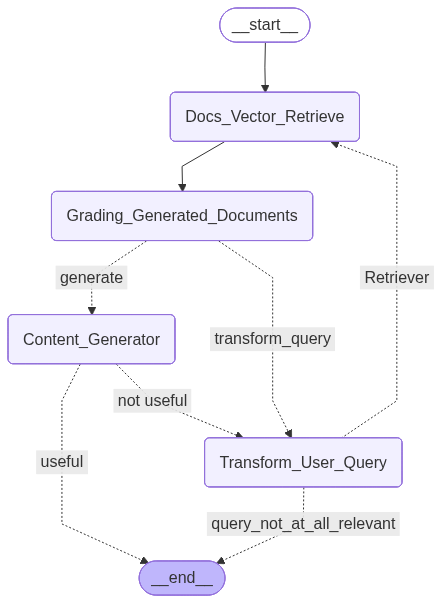

In [207]:
from IPython.display import Image, display # type: ignore
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [101]:
inputs = {"question": "Explain how the different types of agent memory work?"}

In [102]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----DECISION: GENERATE----
----GENERATE----
---CHECK HELLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION ---
---DECISION: GENERATION ADDRESS THE QUESTION ---


AIMessage(content='The two types of agent memory are short-term memory and long-term memory. Short-term memory utilizes in-context learning, where the model learns from the input it receives, and is limited by the context window. Long-term memory, on the other hand, allows the agent to retain and recall information over extended periods by leveraging an external vector store and fast retrieval.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 4566, 'total_tokens': 4638, 'completion_time': 0.212505039, 'completion_tokens_details': None, 'prompt_time': 0.52115233, 'prompt_tokens_details': None, 'queue_time': 0.436039667, 'total_time': 0.733657369}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8891-5355-7e03-a563-637d449e3c34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_

In [103]:
inputs = {"question": "Who is a prompt engineering?"}

In [104]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
this is my document[Document(metadata={'language': 'en', 'title': "Prompt Engineering | Lil'Log", 'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. 

AIMessage(content='Prompt engineering, also known as In-Context Prompting, refers to methods for communicating with large language models (LLMs) to steer their behavior for desired outcomes without updating the model weights. It is an empirical science that requires heavy experimentation and heuristics. The goal of prompt engineering is about alignment and model steerability, aiming to achieve desired outcomes through careful design of input prompts.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 3883, 'total_tokens': 3961, 'completion_time': 0.189370951, 'completion_tokens_details': None, 'prompt_time': 0.219365173, 'prompt_tokens_details': None, 'queue_time': 0.063813204, 'total_time': 0.408736124}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8893-2da9-7782-8835-188671cd9ef6-0', too

In [105]:
inputs = {"question": "what is role of data structure while creating ai agentic pattern?"}

In [106]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----GRADE: DOCUMENT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----DECISION: GENERATE----
----GENERATE----
---CHECK HELLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION ---
---DECISION: GENERATION ADDRESS THE QUESTION ---


AIMessage(content="Data structures play a crucial role in creating AI agentic patterns, particularly in the components of planning, memory, and tool use. The agent's brain, which is the LLM, is complemented by key components such as short-term memory, long-term memory, and external vector stores. Effective data structures, such as tree structures and external vector stores, enable the agent to retain and recall information, plan ahead, and make decisions.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 4939, 'total_tokens': 5027, 'completion_time': 0.291783307, 'completion_tokens_details': None, 'prompt_time': 0.43152216, 'prompt_tokens_details': None, 'queue_time': 0.336566587, 'total_time': 0.723305467}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8894-52f5-7f23-9f7c-346a11d1ad7c-0',

In [162]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="openai/gpt-oss-20b")

# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="qwen/qwen3-next-80b-a3b-instruct:free",
#     temperature=0.8,
# )

In [208]:
inputs = {"question": "what is role of c language and php while creating ai agentic pattern?"}

In [209]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
this is my document[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'language': 'en', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key component

'question was not at all relevant'

In [210]:
inputs = {"question": "Who was a first president of USA?"}

In [211]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----GRADE: DOCUMENT NOT RELEVANT----
----ACCESS GRADED DOCUMENTS----
----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----
this is my document[Document(metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient han

'question was not at all relevant'